# Feature Set Sensitivity Checks

Segmentation robustness checks supported K-Means k=5, with k=6 as the closest alternative. This notebook checks whether the current selected feature set remains the best practical choice before finalising the clustering decision. It does not modify processed data or overwrite `outputs/customer_clusters.csv`.

## Load and Validate Data

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_STATE = 42
N_INIT = 50
SILHOUETTE_SAMPLE_SIZE = 10000
PALETTE = ["#356D8C", "#5C8A72", "#C9822B", "#7C6FA4", "#B4514E", "#4F8F8B"]


In [10]:
selected_model_features = pd.read_csv("../data/processed/selected_model_features.csv")

customer_ids = selected_model_features["customer_id"]
X = selected_model_features.drop(columns=["customer_id"])
non_numeric_columns = X.select_dtypes(exclude="number").columns.tolist()

input_validation = pd.DataFrame(
    {
        "check": [
            "customer_id exists",
            "duplicated customer_id count",
            "missing values count",
            "non-numeric modelling columns",
            "row count",
            "modelling feature count",
        ],
        "value": [
            "customer_id" in selected_model_features.columns,
            customer_ids.duplicated().sum(),
            selected_model_features.isna().sum().sum(),
            non_numeric_columns,
            len(selected_model_features),
            X.shape[1],
        ],
    }
)

if "customer_id" not in selected_model_features.columns:
    raise ValueError("customer_id is missing from selected_model_features.csv")
if customer_ids.duplicated().sum() > 0:
    raise ValueError("Duplicated customer_id values found.")
if selected_model_features.isna().sum().sum() > 0:
    raise ValueError("Missing values found in selected_model_features.csv.")
if non_numeric_columns:
    raise ValueError(f"Non-numeric modelling columns found: {non_numeric_columns}")

input_validation


,check,value
0,customer_id exists,True
1,duplicated customer_id count,0
2,missing values count,0
3,non-numeric modelling columns,[]
4,row count,33038
5,modelling feature count,25


`selected_model_features.csv` is used only as an input. Feature variants are created in memory and are not saved as new processed datasets.

## Build Feature Set Variants

In [11]:
share_columns = [column for column in X.columns if column.startswith("share_")]
gender_columns = [column for column in X.columns if column.startswith("customer_gender")]
degree_columns = [column for column in X.columns if column.startswith("degree_level")]

behaviour_columns = [
    "distinct_stores_visited",
    "lifetime_total_distinct_products",
    "percentage_of_products_bought_promotion",
    "typical_hour",
    "customer_tenure",
    "has_loyalty_card",
    "number_complaints",
]

demographics_behaviour_columns = [
    "age",
    "customer_tenure",
    "kids_home",
    "teens_home",
    "total_children_home",
    "has_children",
    "has_loyalty_card",
    "number_complaints",
    "distinct_stores_visited",
    "lifetime_total_distinct_products",
    "percentage_of_products_bought_promotion",
    "typical_hour",
    *gender_columns,
    *degree_columns,
]

compact_business_columns = [
    "age",
    "customer_tenure",
    "has_loyalty_card",
    "total_children_home",
    "has_children",
    "number_complaints",
    "distinct_stores_visited",
    "lifetime_total_distinct_products",
    "percentage_of_products_bought_promotion",
    "typical_hour",
    "total_lifetime_spend",
    *share_columns,
]

feature_sets = {"current": X}
skipped_variants = []

if all(column in X.columns for column in ["latitude", "longitude"]):
    feature_sets["without_geography"] = X.drop(columns=["latitude", "longitude"])
else:
    skipped_variants.append("without_geography: latitude and longitude are not in selected_model_features")

if "total_lifetime_spend" in X.columns:
    feature_sets["without_total_spend"] = X.drop(columns=["total_lifetime_spend"])
else:
    skipped_variants.append("without_total_spend: total_lifetime_spend is not in selected_model_features")

if all(column in X.columns for column in ["latitude", "longitude", "total_lifetime_spend"]):
    feature_sets["without_geography_and_total_spend"] = X.drop(
        columns=["latitude", "longitude", "total_lifetime_spend"]
    )
else:
    skipped_variants.append(
        "without_geography_and_total_spend: latitude and longitude are not in selected_model_features"
    )

categorical_dummy_columns = gender_columns + degree_columns
if categorical_dummy_columns:
    feature_sets["without_categorical_dummies"] = X.drop(columns=categorical_dummy_columns)
else:
    skipped_variants.append("without_categorical_dummies: no matching dummy columns found")

spend_behaviour_columns = [column for column in [*share_columns, *behaviour_columns] if column in X.columns]
if spend_behaviour_columns:
    feature_sets["spend_shares_only_plus_behaviour"] = X[spend_behaviour_columns]
else:
    skipped_variants.append("spend_shares_only_plus_behaviour: no matching columns found")

available_demographics_behaviour_columns = [
    column for column in demographics_behaviour_columns if column in X.columns
]
if available_demographics_behaviour_columns:
    feature_sets["demographics_behaviour_no_spend"] = X[available_demographics_behaviour_columns]
else:
    skipped_variants.append("demographics_behaviour_no_spend: no matching columns found")

available_compact_business_columns = [column for column in compact_business_columns if column in X.columns]
if available_compact_business_columns:
    feature_sets["compact_business_set"] = X[available_compact_business_columns]
else:
    skipped_variants.append("compact_business_set: no matching columns found")

feature_set_summary = pd.DataFrame(
    {
        "feature_set_variant": list(feature_sets.keys()),
        "number_of_features": [features.shape[1] for features in feature_sets.values()],
    }
)

feature_set_summary


,feature_set_variant,number_of_features
0,current,25
1,without_total_spend,24
2,without_categorical_dummies,20
3,spend_shares_only_plus_behaviour,17
4,demographics_behaviour_no_spend,14
5,compact_business_set,20


In [12]:
pd.DataFrame({"skipped_variant": skipped_variants})


,skipped_variant
0,without_geography: latitude and longitude are ...
1,without_geography_and_total_spend: latitude an...


Geography variants are skipped because latitude and longitude were already excluded from the selected model features. The remaining checks focus on spend, categorical dummies, spending shares, behaviour, and compact business-readable feature groups.

## K-Means k=5 Sensitivity

In [13]:
def calculate_metrics(features, labels, variant, k):
    cluster_counts = pd.Series(labels).value_counts()

    return {
        "feature_set_variant": variant,
        "k": k,
        "number_of_features": features.shape[1],
        "silhouette_score": silhouette_score(
            features,
            labels,
            sample_size=min(SILHOUETTE_SAMPLE_SIZE, len(features)),
            random_state=RANDOM_STATE,
        ),
        "calinski_harabasz_score": calinski_harabasz_score(features, labels),
        "davies_bouldin_score": davies_bouldin_score(features, labels),
        "min_cluster_size": int(cluster_counts.min()),
        "max_cluster_size": int(cluster_counts.max()),
        "min_cluster_percentage": cluster_counts.min() / len(labels) * 100,
        "max_cluster_percentage": cluster_counts.max() / len(labels) * 100,
    }


metric_rows = []

for variant_name, features in feature_sets.items():
    kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=N_INIT)
    labels = kmeans.fit_predict(features)
    metric_rows.append(calculate_metrics(features, labels, variant_name, k=5))

k5_metrics = pd.DataFrame(metric_rows)
k5_metrics.sort_values("silhouette_score", ascending=False)


,feature_set_variant,k,number_of_features,silhouette_score,calinski_harabasz_score,davies_bouldin_score,min_cluster_size,max_cluster_size,min_cluster_percentage,max_cluster_percentage
5,compact_business_set,5,20,0.141156,3841.553195,2.057096,2233,10769,6.758884,32.595799
2,without_categorical_dummies,5,20,0.141156,3841.553195,2.057096,2233,10769,6.758884,32.595799
0,current,5,25,0.135222,3650.808841,2.108630,2234,10841,6.761911,32.813730
3,spend_shares_only_plus_behaviour,5,17,0.134500,4165.445541,2.053745,2175,11482,6.583328,34.753920
4,demographics_behaviour_no_spend,5,14,0.125463,3610.554171,2.034498,3063,10104,9.271142,30.582965
1,without_total_spend,5,24,0.122623,3553.788260,2.182210,2157,10935,6.528846,33.098250


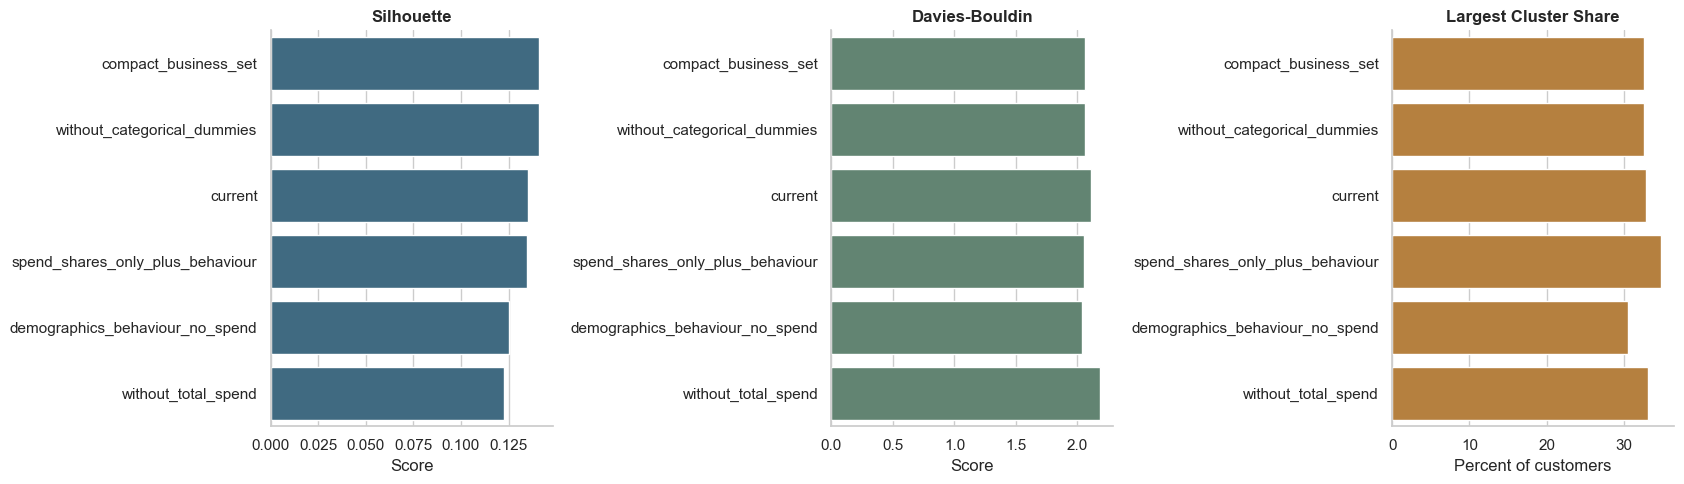

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
plot_metrics = k5_metrics.sort_values("silhouette_score", ascending=False)

sns.barplot(
    data=plot_metrics,
    x="silhouette_score",
    y="feature_set_variant",
    color=PALETTE[0],
    ax=axes[0],
)
axes[0].set_title("Silhouette")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("")

sns.barplot(
    data=plot_metrics,
    x="davies_bouldin_score",
    y="feature_set_variant",
    color=PALETTE[1],
    ax=axes[1],
)
axes[1].set_title("Davies-Bouldin")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("")

sns.barplot(
    data=plot_metrics,
    x="max_cluster_percentage",
    y="feature_set_variant",
    color=PALETTE[2],
    ax=axes[2],
)
axes[2].set_title("Largest Cluster Share")
axes[2].set_xlabel("Percent of customers")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


The current feature set remains competitive, but a simpler feature set without categorical dummies performs slightly better on silhouette and Davies-Bouldin. That suggests categorical dummy variables are not carrying useful clustering separation in the current selected feature set.

## k=6 Check for Current and Best Alternative

In [15]:
best_non_current_variant = (
    k5_metrics[k5_metrics["feature_set_variant"] != "current"]
    .sort_values(["silhouette_score", "davies_bouldin_score"], ascending=[False, True])
    .iloc[0]["feature_set_variant"]
)

for variant_name in ["current", best_non_current_variant]:
    features = feature_sets[variant_name]
    kmeans = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=N_INIT)
    labels = kmeans.fit_predict(features)
    metric_rows.append(calculate_metrics(features, labels, variant_name, k=6))

feature_set_sensitivity_metrics = pd.DataFrame(metric_rows)
feature_set_sensitivity_metrics.to_csv("../outputs/feature_set_sensitivity_metrics.csv", index=False)

feature_set_sensitivity_metrics.sort_values(["k", "silhouette_score"], ascending=[True, False])


,feature_set_variant,k,number_of_features,silhouette_score,calinski_harabasz_score,davies_bouldin_score,min_cluster_size,max_cluster_size,min_cluster_percentage,max_cluster_percentage
5,compact_business_set,5,20,0.141156,3841.553195,2.057096,2233,10769,6.758884,32.595799
2,without_categorical_dummies,5,20,0.141156,3841.553195,2.057096,2233,10769,6.758884,32.595799
0,current,5,25,0.135222,3650.808841,2.108630,2234,10841,6.761911,32.813730
3,spend_shares_only_plus_behaviour,5,17,0.134500,4165.445541,2.053745,2175,11482,6.583328,34.753920
4,demographics_behaviour_no_spend,5,14,0.125463,3610.554171,2.034498,3063,10104,9.271142,30.582965
1,without_total_spend,5,24,0.122623,3553.788260,2.182210,2157,10935,6.528846,33.098250
7,compact_business_set,6,20,0.133237,3594.183122,2.036485,2001,9844,6.056662,29.795992
6,current,6,25,0.127311,3402.138050,2.096260,2008,9816,6.077850,29.711242


k=6 does not become clearly preferable. For both the current feature set and the best non-current alternative, k=5 keeps the stronger silhouette score. k=6 improves largest-cluster balance but loses some separation quality.

## Recommendation

In [17]:
current_k5 = feature_set_sensitivity_metrics[
    (feature_set_sensitivity_metrics["feature_set_variant"] == "current")
    & (feature_set_sensitivity_metrics["k"] == 5)
].iloc[0]

best_k5 = feature_set_sensitivity_metrics[
    feature_set_sensitivity_metrics["k"] == 5
].sort_values(["silhouette_score", "davies_bouldin_score"], ascending=[False, True]).iloc[0]

best_alt_k6 = feature_set_sensitivity_metrics[
    (feature_set_sensitivity_metrics["feature_set_variant"] == best_k5["feature_set_variant"])
    & (feature_set_sensitivity_metrics["k"] == 6)
]

current_feature_set_confirmed = bool(best_k5["feature_set_variant"] == "current")
recommended_feature_set = best_k5["feature_set_variant"]
recommended_k = int(best_k5["k"])

if current_feature_set_confirmed:
    reason = (
        f"The current feature set has the strongest k=5 silhouette ({current_k5['silhouette_score']:.3f}) "
        "among tested interpretable variants."
    )
else:
    reason = (
        f"{recommended_feature_set} has a stronger k=5 silhouette "
        f"({best_k5['silhouette_score']:.3f}) than the current feature set "
        f"({current_k5['silhouette_score']:.3f}), with similar cluster balance."
    )

closest_alternative = (
    f"current k=5" if recommended_feature_set != "current" else f"{best_non_current_variant} k=5"
)

if len(best_alt_k6):
    k6_note = (
        f"k=6 for {recommended_feature_set} has silhouette "
        f"{best_alt_k6.iloc[0]['silhouette_score']:.3f}, so it is not clearly better than k=5."
    )
else:
    k6_note = "k=6 was checked for current and the best non-current alternative."

feature_set_sensitivity_recommendation = pd.DataFrame(
    [
        {
            "recommended_feature_set": recommended_feature_set,
            "recommended_k": recommended_k,
            "reason": reason,
            "whether_current_feature_set_is_confirmed": current_feature_set_confirmed,
            "closest_alternative": closest_alternative,
            "caveat": (
                f"The improvement is modest and no cluster output was overwritten. {k6_note} "
                "Review whether excluding categorical dummies improves business interpretation before finalising."
            ),
        }
    ]
)

feature_set_sensitivity_recommendation.to_csv(
    "../outputs/feature_set_sensitivity_recommendation.csv",
    index=False,
)

feature_set_sensitivity_recommendation


,recommended_feature_set,recommended_k,reason,whether_current_feature_set_is_confirmed,closest_alternative,caveat
0,compact_business_set,5,compact_business_set has a stronger k=5 silhou...,False,current k=5,The improvement is modest and no cluster outpu...


The final recommendation is to keep K-Means k=5 under consideration, but revisit the selected feature set before treating the current cluster output as final. No simpler feature set radically changes the picture, but excluding categorical dummies gives a modest improvement and is easier to explain.

## Output Check

In [18]:
output_check = pd.DataFrame(
    {
        "output": [
            "outputs/feature_set_sensitivity_metrics.csv",
            "outputs/feature_set_sensitivity_recommendation.csv",
        ],
        "rows": [
            len(feature_set_sensitivity_metrics),
            len(feature_set_sensitivity_recommendation),
        ],
    }
)

output_check


,output,rows
0,outputs/feature_set_sensitivity_metrics.csv,8
1,outputs/feature_set_sensitivity_recommendation...,1
